In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob, os
import wrf
from netCDF4 import Dataset

In [7]:
# ── Simulation definitions ─────────────────────────────────────────────────────
base_111m = '/glade/derecho/scratch/gduine/mountain_fire/111m/'
base_1km  = '/glade/derecho/scratch/gduine/mountain_fire/1km/'

simulations = [
    {'label': 'No fire (ref)',  'dir': base_111m + 'ifire0/ref/',       'domain': 'd04', 'color': 'gray',   'lw': 1.5, 'ls': '-'},
    {'label': 'z0 double',      'dir': base_111m + 'ifire0/z0_double/', 'domain': 'd04', 'color': 'blue',   'lw': 1.5, 'ls': '--'},
    {'label': 'Fire (ifire2)',  'dir': base_111m + 'ifire2/',           'domain': 'd04', 'color': 'red',    'lw': 1.5, 'ls': '-'},
    {'label': '1 km',           'dir': base_1km,                        'domain': 'd03', 'color': 'green',  'lw': 1.5, 'ls': '-'},
]

# ── Station locations ──────────────────────────────────────────────────────────
stations = {
    'START':       {'lat': 34.318,    'lon': -118.968},
    'SPOT':        {'lat': 34.2528,   'lon': -119.0284},
    'Spot Valley': {'lat': 34.271191, 'lon': -119.015999},
}

out_dir = '.'

In [8]:
# ── Extract time series at all stations for one simulation ─────────────────────
def extract_timeseries(sim, stations):
    domain  = sim['domain']
    wrf_dir = sim['dir']

    files = sorted(glob.glob(os.path.join(wrf_dir, f'wrfout_{domain}_*')))
    if not files:
        print(f'  No files found in {wrf_dir}')
        return None
    print(f'  {sim["label"]}: {len(files)} files')

    # Grid indices for each station (from first file)
    with Dataset(files[0]) as nc0:
        lats_list = [s['lat'] for s in stations.values()]
        lons_list = [s['lon'] for s in stations.values()]
        xy_pts    = wrf.ll_to_xy(nc0, lats_list, lons_list)

    times   = []
    u10_ts  = {name: [] for name in stations}
    v10_ts  = {name: [] for name in stations}
    ust_ts  = {name: [] for name in stations}
    pblh_ts = {name: [] for name in stations}
    hfx_ts  = {name: [] for name in stations}

    for fName in files:
        nc      = Dataset(fName)
        n_times = nc.dimensions['Time'].size

        for idt in range(n_times):
            timeWRF = wrf.getvar(nc, 'Times', idt)
            times.append(pd.to_datetime(wrf.to_np(timeWRF)))

            U10_np  = wrf.to_np(wrf.getvar(nc, 'U10',  idt))
            V10_np  = wrf.to_np(wrf.getvar(nc, 'V10',  idt))
            UST_np  = wrf.to_np(wrf.getvar(nc, 'UST',  idt))
            PBLH_np = wrf.to_np(wrf.getvar(nc, 'PBLH', idt))
            HFX_np  = wrf.to_np(wrf.getvar(nc, 'HFX',  idt))

            for i, name in enumerate(stations):
                ix = int(xy_pts[0, i])
                iy = int(xy_pts[1, i])
                u10_ts[name].append(float(U10_np[iy, ix]))
                v10_ts[name].append(float(V10_np[iy, ix]))
                ust_ts[name].append(float(UST_np[iy, ix]))
                pblh_ts[name].append(float(PBLH_np[iy, ix]))
                hfx_ts[name].append(float(HFX_np[iy, ix]))

        nc.close()

    # Convert to PST
    times = pd.DatetimeIndex(times) - pd.Timedelta(hours=8)

    result = {'times': times}
    for name in stations:
        u = np.array(u10_ts[name])
        v = np.array(v10_ts[name])
        result[name] = {
            'wspd': np.sqrt(u**2 + v**2),
            'wdir': (180 + np.degrees(np.arctan2(u, v))) % 360,
            'ust':  np.array(ust_ts[name]),
            'pblh': np.array(pblh_ts[name]),
            'hfx':  np.array(hfx_ts[name]),
        }

    return result


# ── Run extraction for all simulations ────────────────────────────────────────
all_data = {}
for sim in simulations:
    print(f'Processing {sim["label"]} ...')
    all_data[sim['label']] = extract_timeseries(sim, stations)

Processing No fire (ref) ...
  No fire (ref): 38 files
Processing z0 double ...
  z0 double: 38 files
Processing Fire (ifire2) ...
  Fire (ifire2): 38 files
Processing 1 km ...
  1 km: 79 files


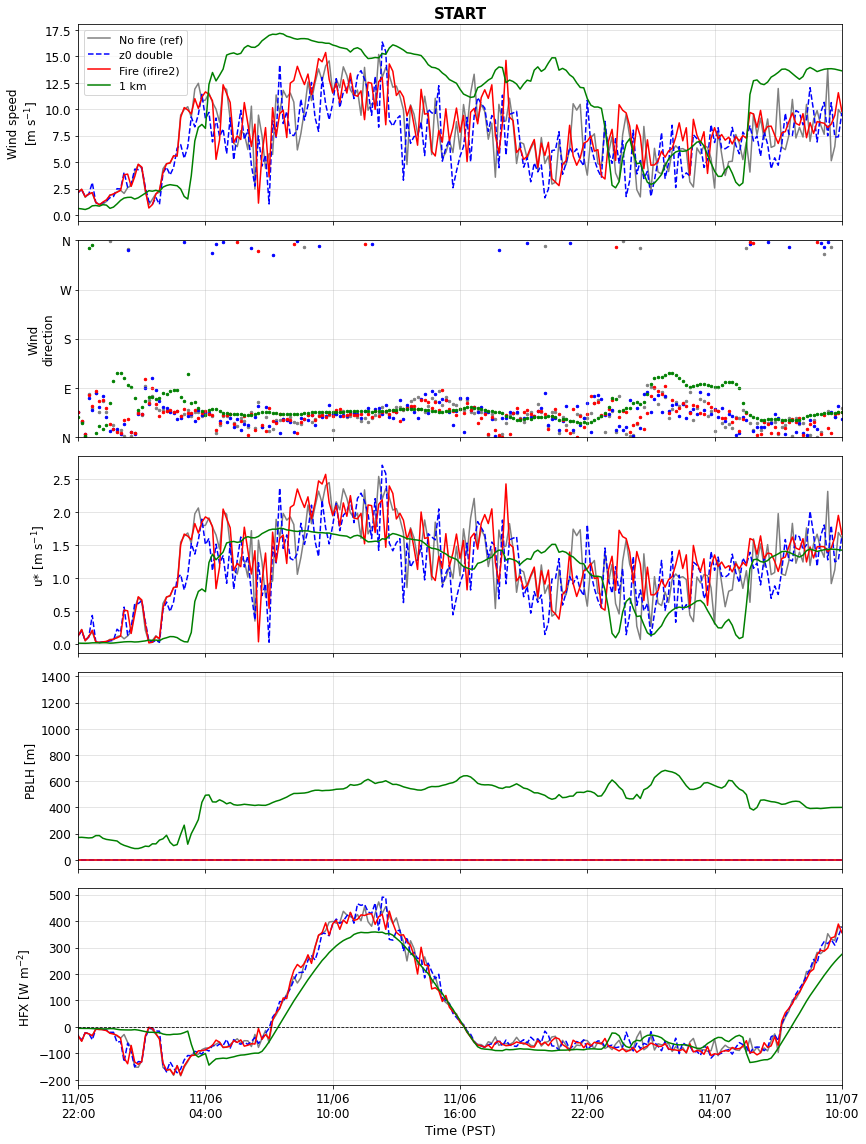

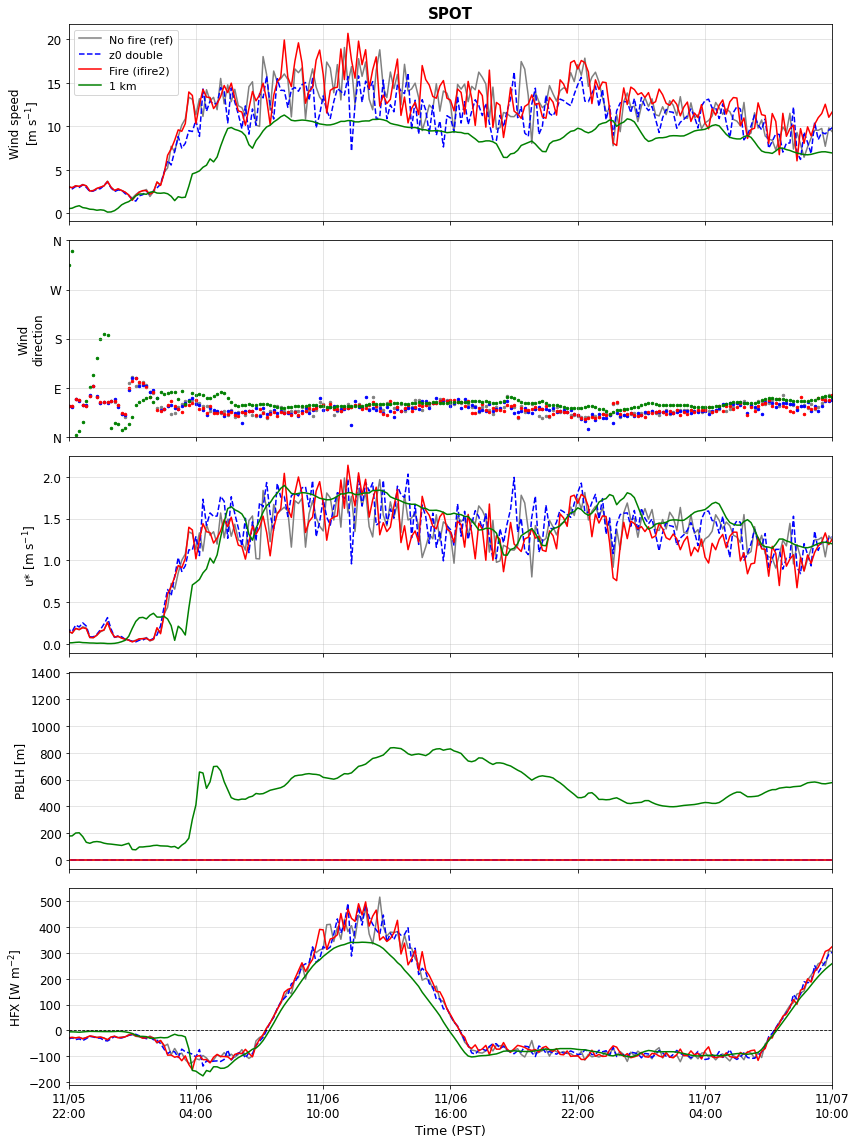

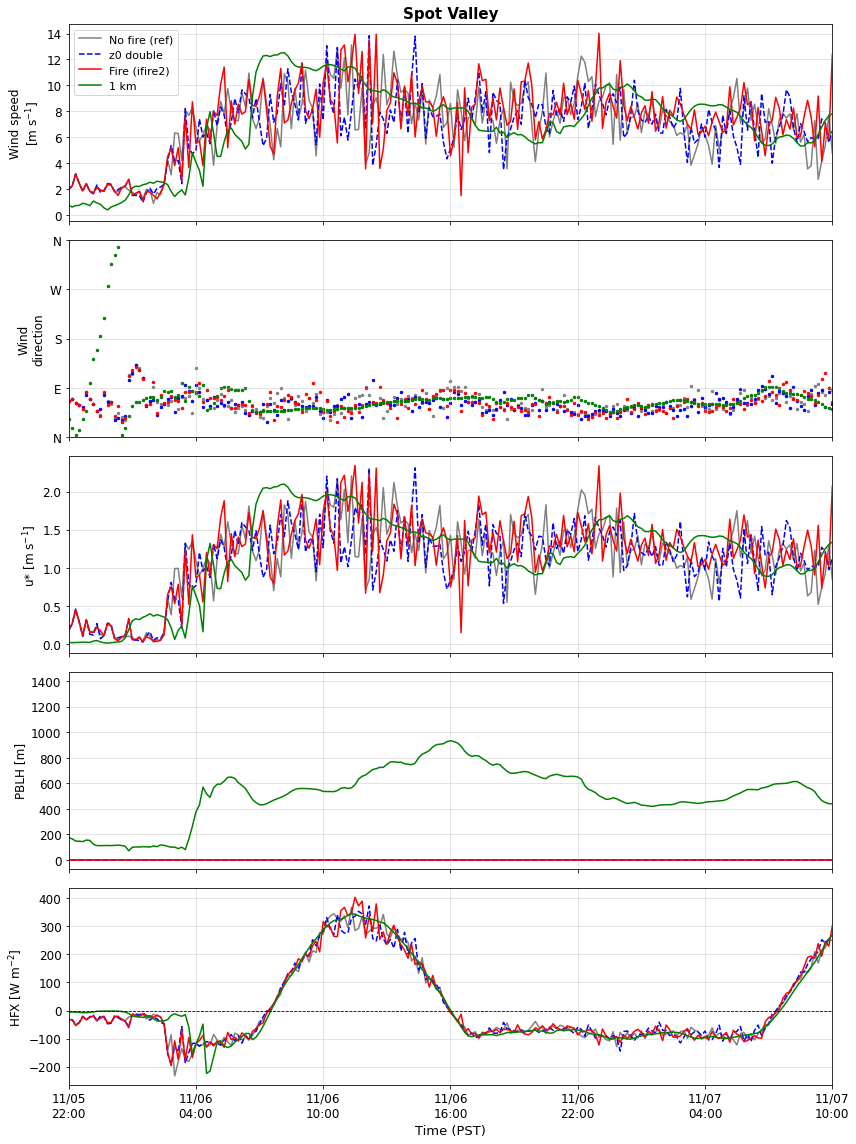

Done!


In [10]:
# ── Plot: one figure per station, 5 panels ────────────────────────────────────
for st_name in stations:
    fig, (ax_spd, ax_dir, ax_ust, ax_pblh, ax_hfx) = plt.subplots(
        5, 1, figsize=(12, 16), sharex=True)

    for sim in simulations:
        data = all_data[sim['label']]
        if data is None:
            continue
        times = data['times']
        d     = data[st_name]

        kw = dict(color=sim['color'], lw=sim['lw'], ls=sim['ls'], label=sim['label'])
        ax_spd.plot(times,  d['wspd'], **kw)
        ax_ust.plot(times,  d['ust'],  **kw)
        ax_pblh.plot(times, d['pblh'], **kw)
        ax_hfx.plot(times,  d['hfx'],  **kw)
        # scatter for direction avoids spurious lines at the 360°→0° wrap
        ax_dir.scatter(times, d['wdir'], color=sim['color'], s=6, label=sim['label'])

    # --- wind speed ---
    ax_spd.set_title(st_name, fontsize=15, fontweight='bold')
    ax_spd.set_ylabel('Wind speed\n[m s$^{-1}$]', fontsize=12)
    ax_spd.legend(fontsize=11, loc='upper left')
    ax_spd.grid(True, alpha=0.4)

    # --- wind direction ---
    ax_dir.set_ylabel('Wind\ndirection', fontsize=12)
    ax_dir.set_ylim(0, 360)
    ax_dir.set_yticks([0, 90, 180, 270, 360])
    ax_dir.set_yticklabels(['N', 'E', 'S', 'W', 'N'])
    ax_dir.grid(True, alpha=0.4)

    # --- friction velocity ---
    ax_ust.set_ylabel('u* [m s$^{-1}$]', fontsize=12)
    ax_ust.grid(True, alpha=0.4)

    # --- PBL height ---
    ax_pblh.set_ylabel('PBLH [m]', fontsize=12)
    ax_pblh.grid(True, alpha=0.4)

    # --- sensible heat flux ---
    ax_hfx.set_ylabel('HFX [W m$^{-2}$]', fontsize=12)
    ax_hfx.axhline(0, color='k', lw=0.8, ls='--')
    ax_hfx.grid(True, alpha=0.4)
    ax_hfx.set_xlabel('Time (PST)', fontsize=13)
    ax_hfx.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d\n%H:%M'))
    ax_hfx.xaxis.set_major_locator(mdates.HourLocator(interval=6))

    for ax in (ax_spd, ax_dir, ax_ust, ax_pblh, ax_hfx):
        ax.tick_params(labelsize=12)

    ax_spd.set_xlim(pd.Timestamp('2024-11-05 22:00'), pd.Timestamp('2024-11-07 10:00'))
    
    plt.tight_layout()
    fname = st_name.replace(' ', '_').lower()
    fig.savefig(os.path.join(out_dir, f'timeseries_winds_4sims_{fname}.jpg'),
                dpi=120, bbox_inches='tight')
    plt.show()

print('Done!')